In [1]:
import pandas as pd
import missingno as msn

In [2]:
df_1 = pd.read_excel('../data/nova_pay_transactions.xlsx')
df_1.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [3]:
print(f'Total number of rows: {df_1.shape[0]}')
print(f'Total number of columns: {df_1.shape[1]}')

Total number of rows: 10200
Total number of columns: 26


In [4]:
df_2 = pd.read_csv('../data/nova_pay_fraud_boost.csv')
df_2.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,a3d2ad59-8e0f-4b33-b9cf-48bdca536e2f,22c3f4f2-23a3-4f40-adc0-307dff722216,2023-12-03 01:18:32.573611+00:00,UK,GBP,NGN,web,2267.24,2834.05,34.35,...,0.929,low,24,0.027,1,0.312,8,11,0.22,1
1,ff87e7e7-7647-4059-8691-1a6d3e5251c2,db2b26f9-e12f-49d9-bf2f-73ae77a0d81f,2023-12-03 13:05:30.573611+00:00,US,USD,NGN,web,624.63,624.63,9.78,...,1.000,low,14,0.566,0,0.311,6,7,0.00,1
2,5664b84f-2c90-4539-a5d9-6ec3bec881c5,74224638-f8fd-4ca1-91b0-244ffb6f7310,2023-12-05 03:38:56.573611+00:00,CA,CAD,INR,web,642.36,475.35,11.43,...,1.000,low,65,0.386,1,0.425,7,8,0.12,1
3,771f1ad8-3902-4531-bb3c-6a4fa37ae438,93ca016d-93a2-4b86-b170-8871a9e4561e,2023-12-05 14:58:16.573611+00:00,US,USD,PHP,web,938.16,938.16,14.58,...,1.000,low,29,0.337,2,0.758,6,7,0.10,1
4,41dffb0b-2515-46ff-814c-724fa0f50c99,6ab3647c-b86e-4018-8fba-4077e0bf986a,2023-12-06 13:59:05.573611+00:00,US,USD,MXN,mobile,114.51,114.51,1.97,...,0.254,standard,1095,0.566,0,0.225,1,2,0.00,0


In [5]:
print(f'Total number of rows: {df_2.shape[0]}')
print(f'Total number of columns: {df_2.shape[1]}')

Total number of rows: 1200
Total number of columns: 26


In [6]:
df = pd.concat([df_1, df_2], axis=0,)
df.shape

(11400, 26)

### Data Dictionary
#### Definition of columns
 - **transaction_id**: Unique Identifier of the transaction.
 - **customer_id**: Unique Identifier of the customer.
 - **timestamp**: Time and Date the transaction was made.
 - **home_country**: The country the customer resides in.
 - **source_currency**: The currency of the country the customer currently resides in.
 - **dest_currency**: The currency of the country the recipient resides in.
 - **channel**: The means through which the transfer was made.
 - **amount_src**: The amount that was deducted from the customer's account.
 - **amount_usd**: The USD equvilaent of the amount that was deducted from the customer's account.
 - **fee**: The fees that was charged for the transactions.
 - **exchange_rate_src_to_dest**: The exchange rate that was used for the conversion.
 - **device_id**: The unique identifier of the device that the customer used.
 - **new_device**: Whether the device used was a new device or has been used before.
 - **ip_address**: The ip address of the device that was used.
 - **ip_country**: The country that the Ip address of the device came from.
 - **location_mismatch**: Whether there is a mismatch between the customer’s home country and the Ip country.
 - **ip_risk_score**: The risk score assigned to the Ip that customer used.
 - **kyc_tier**: Know Your Customer verification level of the customer.
 - **account_age_days**: The age of the customer**s account in number of days.
 - **device_trust_score**: The score assigned to the device being used.
 - **chargeback_history_count**: The number of times the customer had a transaction charged back.
 - **risk_score_internal**: Internal risk score calculated for this transaction.
 - **txn_velocity_1h**: Number of transactions by this customer in the past 1 hours.
 - **txn_velocity_24h**: Number of transactions by this customer in the past 24 hours.
 - **corridor_risk**: Risk score associated with this particular currency corridor.
 - **is_fraud** : Target variable indicating whether the transaction was a fraudulent or not.

#### Meaning of codes
- source_currency
    - **'USD'** -> United States Dollar
    - **''CAD'** -> Canadian Dollar
    - **''GBP'** -> British Pound Sterling

- dest_currency
    - **'CAD'** -> Canadian Dollar
    - **'MXN'** -> Mexican Peso
    - **'CNY'** -> Chinese Yuan (Renminbi)
    - **'EUR'** -> Euro
    - **'INR'** -> Indian Rupee
    - **'GBP'** -> British Pound Sterling
    - **'PHP'** -> Philippine Peso
    - **'NGN'** -> Nigerian Naira
    - **'USD'** -> United States Dollar

In [7]:
with pd.option_context('display.max_columns', None):
    display(df[df['is_fraud']== 1].head(5))

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
9,d74c81c0-bf5d-4184-8ce2-27fb753cb1c6,f7531a78-8bbe-4a85-b1e8-a0650edddc72,2022-10-04 21:20:42.468549+00:00,US,USD,PHP,web,302.55,302.55,5.26,58.823529,3df8c73d-b716-4a6e-8172-d2b7359b60b2,False,103.237.21.29,US,False,0.413,standard,1016,0.944,0,0.247,0,0,0.10,1
46,af10ed77-e5e8-48b1-8111-ad48872985ac,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,2022-10-08 14:19:34.468549+00:00,UK,GBP,EUR,web,146.41,183.02,3.23,1.157407,6bd0a6a0-6b99-47de-8833-e05cd3c7a119,False,170.75.234.234,US,True,0.336,standard,4,0.892,0,0.407,0,0,0.05,1
92,f2bd960e-8bdd-4598-8fef-9b76eea32ca0,657acfcc-b226-4a5f-b39c-f1c1cc2718b5,2022-10-15 04:49:20.468549+00:00,CA,CAD,CNY,web,506.98,375.17,8.93,5.285714,b3fc0cef-92dd-40b3-9205-170713d390f8,False,163.241.235.58,CA,False,0.303,standard,272,0.792,0,0.048,0,0,0.00,1
147,fd202193-2e27-4b11-acd0-71bbf3c9bb1d,d63571e6-4a0b-4339-9d12-3dd2f2c07d13,2022-10-20 16:02:19.468549+00:00,CA,CAD,PHP,mobile,9993.58,7395.25,150.50,43.529412,bbd2294b-2c1d-47c4-91e4-c86985e85fce,False,65.31.127.68,US,True,0.462,standard,564,0.658,0,0.400,0,0,0.00,1
338,e902992d-65db-406b-8335-45ecea0e8b93,d71c91b4-fee8-4104-9856-a5c6109a62e3,2022-11-11 20:41:43.468549+00:00,US,USD,NGN,mobile,123.15,NaN,NaN,1111.111111,130d3281-3ad5-4d7e-9256-c8eea68b6278,False,NaN,NaN,False,0.535,NaN,298,NaN,0,0.166,0,0,0.25,1


How much does the recieptent actually recieve is not provided so we may have to create that column using the exchange rate.

is there anyone who sent from USD to USD?



In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11400 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  float64
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  object 
 

**Key Observations**:

- Timestamp is not in the proper format
- Quite a number of columns have missing values

### Unique Values

In [9]:
cat_cols = df.select_dtypes(include='object')

for col in cat_cols:
    print(f'{df[col].name}: {df[col].nunique()} unique values')
    print('\n')

transaction_id: 11200 unique values


customer_id: 1315 unique values


timestamp: 11141 unique values


home_country: 4 unique values


source_currency: 3 unique values


dest_currency: 9 unique values


channel: 9 unique values


device_id: 2113 unique values


ip_address: 10900 unique values


ip_country: 5 unique values


kyc_tier: 10 unique values




### Checking and Handling duplicates

In [10]:
print(f'Number of duplicated rows: {df.duplicated().sum()} rows')
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print('\n')
    print('Dropping duplicated rows...')
    print(f'Number of duplicated rows: {df.duplicated().sum()} rows')
else:
    print('')

Number of duplicated rows: 200 rows


Dropping duplicated rows...
Number of duplicated rows: 0 rows


In [11]:
if df.duplicated().sum() > 0:
    print(f'Confirming that duplicates have been dropped: {df.duplicated().sum()} rows')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11200 non-null  object 
 1   customer_id                11200 non-null  object 
 2   timestamp                  11171 non-null  object 
 3   home_country               11200 non-null  object 
 4   source_currency            11200 non-null  object 
 5   dest_currency              11200 non-null  object 
 6   channel                    11200 non-null  object 
 7   amount_src                 11200 non-null  float64
 8   amount_usd                 10900 non-null  float64
 9   fee                        10910 non-null  float64
 10  exchange_rate_src_to_dest  11200 non-null  float64
 11  device_id                  11200 non-null  object 
 12  new_device                 11200 non-null  bool   
 13  ip_address                 10900 non-null  object 
 

### Missing Values

In [13]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   300
fee                          290
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   300
ip_country                   297
location_mismatch              0
ip_risk_score                  0
kyc_tier                     297
account_age_days               0
device_trust_score           290
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

<Axes: >

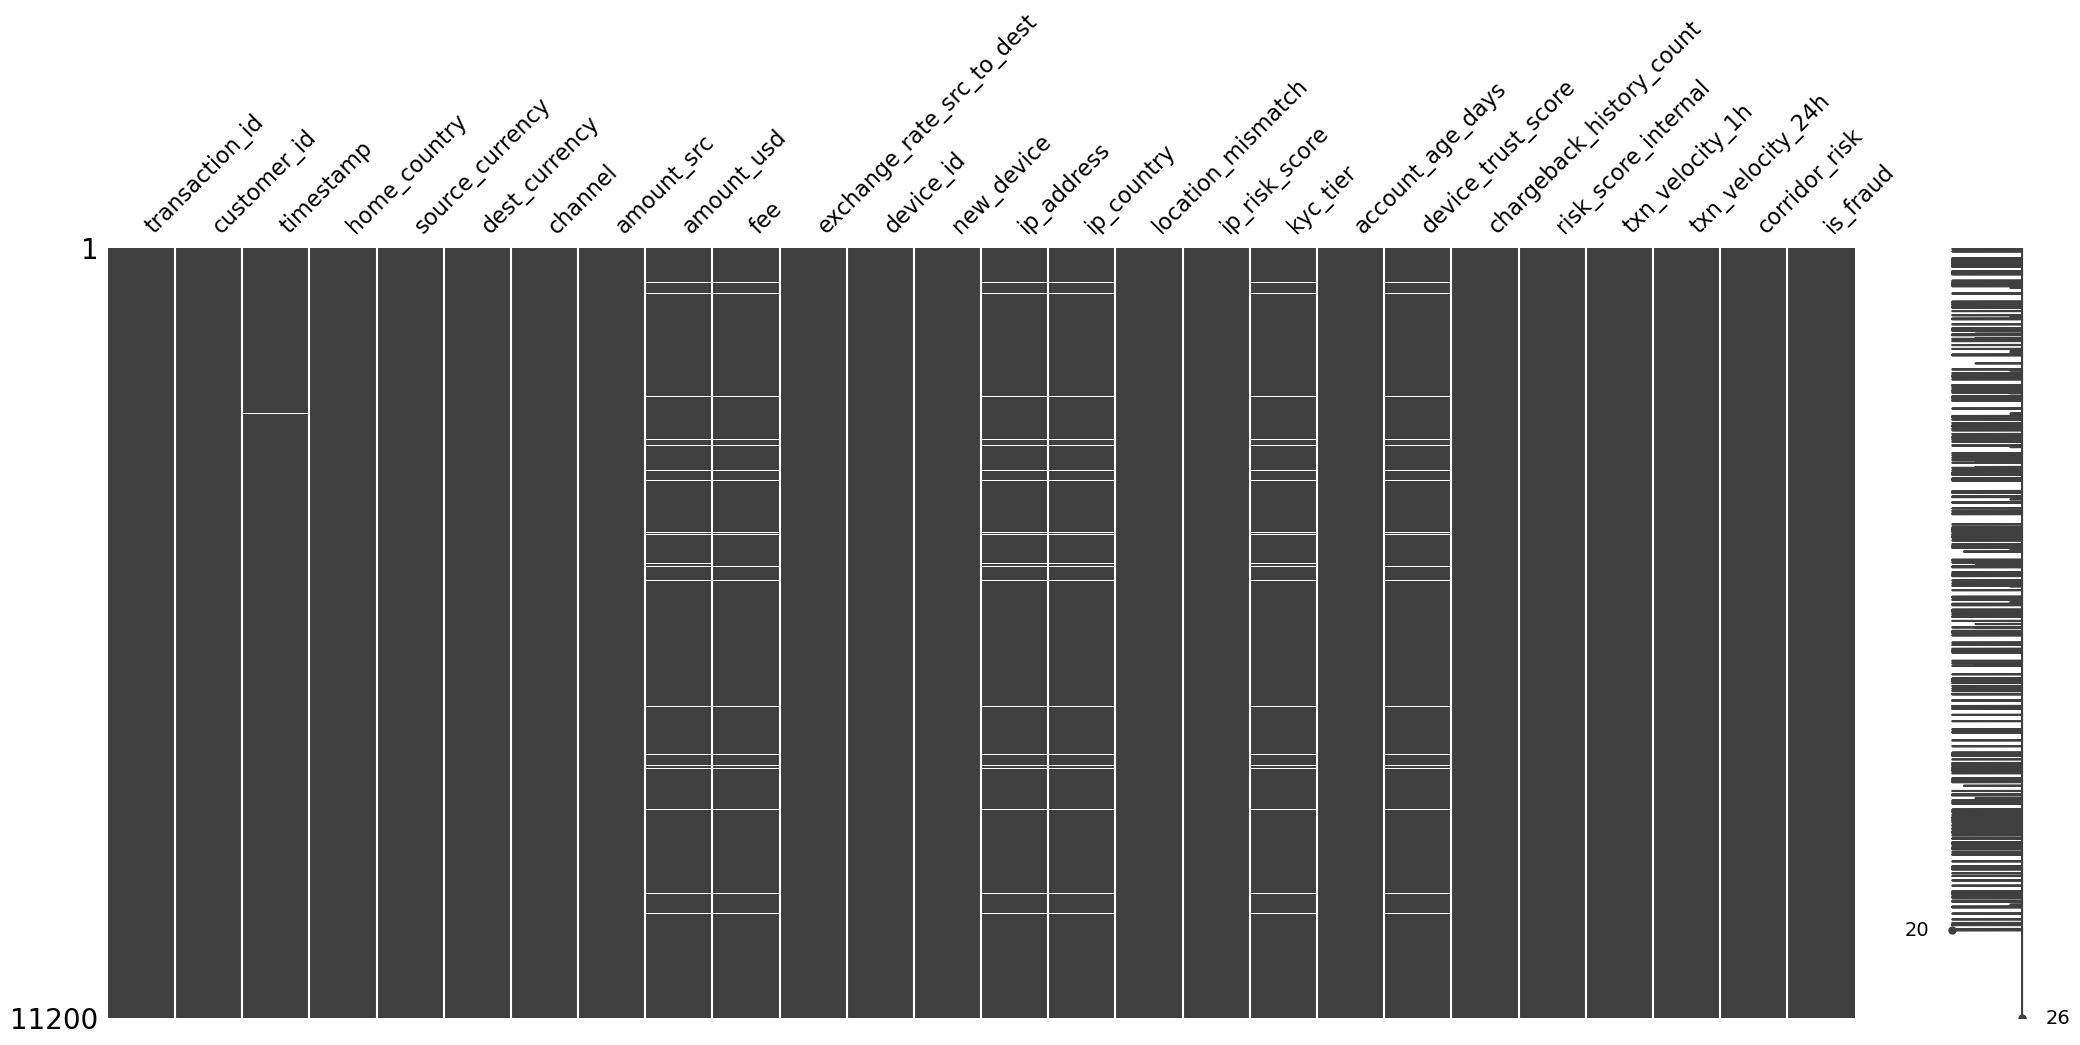

In [14]:
msn.matrix(df)

In [15]:
df.isnull().mean() * 100

transaction_id               0.000000
customer_id                  0.000000
timestamp                    0.258929
home_country                 0.000000
source_currency              0.000000
dest_currency                0.000000
channel                      0.000000
amount_src                   0.000000
amount_usd                   2.678571
fee                          2.589286
exchange_rate_src_to_dest    0.000000
device_id                    0.000000
new_device                   0.000000
ip_address                   2.678571
ip_country                   2.651786
location_mismatch            0.000000
ip_risk_score                0.000000
kyc_tier                     2.651786
account_age_days             0.000000
device_trust_score           2.589286
chargeback_history_count     0.000000
risk_score_internal          0.000000
txn_velocity_1h              0.000000
txn_velocity_24h             0.000000
corridor_risk                0.000000
is_fraud                     0.000000
dtype: float

IP address is a unique identifier of the device that the customer used in making the transaction. It can therefore not be filled and has to be dropped since there is no way of knowing which IP address was used.

In [16]:
missing_ip = df[df['ip_address'].isnull()]

In [17]:
missing_ip['is_fraud'].value_counts()

is_fraud
0    293
1      7
Name: count, dtype: int64

In [18]:
missing_ip['amount_usd'].sum()

np.float64(0.0)

In [19]:
missing_ip.groupby('is_fraud')['amount_usd'].sum()

is_fraud
0    0.0
1    0.0
Name: amount_usd, dtype: float64

In [20]:
df.dropna(subset='ip_address', inplace=True)
df.isnull().sum()

transaction_id                0
customer_id                   0
timestamp                    29
home_country                  0
source_currency               0
dest_currency                 0
channel                       0
amount_src                    0
amount_usd                    0
fee                           0
exchange_rate_src_to_dest     0
device_id                     0
new_device                    0
ip_address                    0
ip_country                    0
location_mismatch             0
ip_risk_score                 0
kyc_tier                      0
account_age_days              0
device_trust_score            0
chargeback_history_count      0
risk_score_internal           0
txn_velocity_1h               0
txn_velocity_24h              0
corridor_risk                 0
is_fraud                      0
dtype: int64

In [21]:
df[df['timestamp'].isnull()]

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
158,e6ef7b85-c19f-43fa-befa-743e37c62583,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,PHP,mobile,248.92,248.92,5.56,...,0.197,enhanced,367,0.939,0,0.176,0,0,0.10,0
160,2b64ca36-f140-4de4-9cc8-c678255402a9,d71c91b4-fee8-4104-9856-a5c6109a62e3,NaN,US,USD,CNY,web,75.44,75.44,1.31,...,0.353,standard,298,0.336,0,0.166,0,0,0.00,0
578,b371fb34-0744-4b90-b33d-237b95b0cd52,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,INR,mobile,251.95,251.95,5.68,...,0.424,enhanced,367,0.939,0,0.176,0,0,0.00,0
1003,3e96cacd-3722-469f-95c1-6dce5ba73aa6,7bd5200c-5d19-44f0-9afe-8b339a05366b,NaN,US,USD,GBP,web,51.22,51.22,1.23,...,0.569,standard,147,0.401,0,0.391,0,1,0.00,0
1325,c646535b-dd51-4d09-b155-e603bbafdc7e,70a93d26-8e3a-4179-900c-a4a7a74d08e5,NaN,US,USD,USD,mobile,9993.44,9993.44,150.77,...,0.398,enhanced,257,0.894,0,0.257,0,1,0.00,0
1501,f340c84f-8021-483c-9a7e-b1fae29a3859,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,NaN,US,USD,GBP,web,165.80,165.80,3.62,...,0.337,enhanced,367,0.939,0,0.176,0,0,0.00,0
1522,fcf3662d-6acd-4303-902f-0a46cefda734,7bd5200c-5d19-44f0-9afe-8b339a05366b,NaN,US,USD,GBP,mobile,90.11,90.11,2.42,...,0.268,standard,147,0.551,0,0.391,0,0,0.00,0
1780,c99dc8d7-24b9-4527-93dc-29cb6711bbe6,7041b9c1-3719-4ca8-9a6b-811b47cea6c0,NaN,UK,GBP,PHP,web,41.10,51.37,2.13,...,0.234,standard,4,0.892,0,0.407,0,0,0.00,1
2053,bf335e6c-a6bc-4fa3-96ed-516d8d7ca793,af8ca4c4-8703-4c55-b66c-2b76cd70040d,NaN,US,USD,PHP,mobile,126.75,126.75,3.55,...,0.257,standard,1018,0.934,0,0.087,0,0,0.10,0
2112,611e6035-5389-45bd-a467-6aaf83493a0a,402cccc9-28de-45b3-9af7-cc5302aa1f93,NaN,US,USD,INR,mobile,56.95,56.95,1.78,...,0.304,standard,263,0.522,0,0.223,0,1,0.00,0


The data in the timestamp column appears to be missing by random and because it consituents just a small fraction of rows(i.e. 29 rows) we would be dropping them.

In [22]:
df.dropna(inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10871 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10871 non-null  object 
 1   customer_id                10871 non-null  object 
 2   timestamp                  10871 non-null  object 
 3   home_country               10871 non-null  object 
 4   source_currency            10871 non-null  object 
 5   dest_currency              10871 non-null  object 
 6   channel                    10871 non-null  object 
 7   amount_src                 10871 non-null  float64
 8   amount_usd                 10871 non-null  float64
 9   fee                        10871 non-null  float64
 10  exchange_rate_src_to_dest  10871 non-null  float64
 11  device_id                  10871 non-null  object 
 12  new_device                 10871 non-null  bool   
 13  ip_address                 10871 non-null  object 
 

In [24]:
import os
os.makedirs('../output', exist_ok=True)
df.to_csv('../output/transactions_data_non_nulls.csv', index=False)